<a href="https://colab.research.google.com/github/hibamadathil-cmd/mental-health-status-classification-from-social-media-text-predictive-project-3/blob/Member-2-%E2%80%94-Model-Development-%26-Evaluation/Member_2_%E2%80%94_Model_Development_%26_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!git clone https://github.com/hibamadathil-cmd/mental-health-status-classification-from-social-media-text-predictive-project-3.git

Cloning into 'mental-health-status-classification-from-social-media-text-predictive-project-3'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 21 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 3.02 MiB | 9.89 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [24]:
import os
os.chdir("mental-health-status-classification-from-social-media-text-predictive-project-3")
!ls  # This shows all files in the repo

cleaned_dataset.csv
Dataset.zip
mental_health_classifier.ipynb
README.md
Stage1_Problem_Definition_and_Literature_Review.md
Stage2_Data_Collection_and_Understanding.md
Stage3_Preprocessing_and_Cleaning.md


In [3]:
import zipfile

with zipfile.ZipFile("Dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

!ls dataset/  # See what's inside

data_to_be_cleansed.csv


In [25]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")
print(df.shape)
df.head()

(5948, 5)


,clean_title,clean_text,clean_combined,text_missing_flag,target
0,regular check post information rules wikis,welcome check post place take moment share goi...,regular check post information rules wikis wel...,0,1
1,broken least understood rules helpers may invi...,understand people reply immediately invitation...,broken least understood rules helpers may invi...,0,1
2,haven’t touched even hugged long can’t even re...,anyone else miss physical touch crave badly…,haven’t touched even hugged long can’t even re...,0,1
3,depressed embarrassing,i’m ashamed everyone everything feels far away...,depressed embarrassing i’m ashamed everyone ev...,0,1
4,desperate friend feel loved someone,really need friend even single best friend des...,desperate friend feel loved someone really nee...,0,1


In [27]:
# Just go to File → Open notebook → GitHub tab
# Paste this URL:
# https://github.com/hibamadathil-cmd/mental-health-status-classification-from-social-media-text-predictive-project-3

In [28]:
!git clone https://github.com/hibamadathil-cmd/mental-health-status-classification-from-social-media-text-predictive-project-3.git
import os
os.chdir("mental-health-status-classification-from-social-media-text-predictive-project-3")

import zipfile
with zipfile.ZipFile("Dataset.zip", "r") as z:
    z.extractall(".")

import os
print("Files available:")
for f in os.listdir("."):
    print(" ", f)

Cloning into 'mental-health-status-classification-from-social-media-text-predictive-project-3'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 21 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 3.02 MiB | 11.01 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Files available:
  Stage2_Data_Collection_and_Understanding.md
  cleaned_dataset.csv
  Stage3_Preprocessing_and_Cleaning.md
  .git
  README.md
  data_to_be_cleansed.csv
  mental_health_classifier.ipynb
  Stage1_Problem_Definition_and_Literature_Review.md
  Dataset.zip


In [29]:
import os
os.chdir("/content/mental-health-status-classification-from-social-media-text-predictive-project-3")

import pandas as pd
df = pd.read_csv("cleaned_dataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(5948, 5)
['clean_title', 'clean_text', 'clean_combined', 'text_missing_flag', 'target']


,clean_title,clean_text,clean_combined,text_missing_flag,target
0,regular check post information rules wikis,welcome check post place take moment share goi...,regular check post information rules wikis wel...,0,1
1,broken least understood rules helpers may invi...,understand people reply immediately invitation...,broken least understood rules helpers may invi...,0,1
2,haven’t touched even hugged long can’t even re...,anyone else miss physical touch crave badly…,haven’t touched even hugged long can’t even re...,0,1
3,depressed embarrassing,i’m ashamed everyone everything feels far away...,depressed embarrassing i’m ashamed everyone ev...,0,1
4,desperate friend feel loved someone,really need friend even single best friend des...,desperate friend feel loved someone really nee...,0,1


In [30]:
print("Columns:", df.columns.tolist())
print("Sample data:")
print(df.head(3))

Columns: ['clean_title', 'clean_text', 'clean_combined', 'text_missing_flag', 'target']
Sample data:
                                         clean_title  \
0         regular check post information rules wikis   
1  broken least understood rules helpers may invi...   
2  haven’t touched even hugged long can’t even re...   

                                          clean_text  \
0  welcome check post place take moment share goi...   
1  understand people reply immediately invitation...   
2       anyone else miss physical touch crave badly…   

                                      clean_combined  text_missing_flag  \
0  regular check post information rules wikis wel...                  0   
1  broken least understood rules helpers may invi...                  0   
2  haven’t touched even hugged long can’t even re...                  0   

   target  
0       1  
1       1  
2       1  


In [31]:
print("ALL columns:", df.columns.tolist())
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

ALL columns: ['clean_title', 'clean_text', 'clean_combined', 'text_missing_flag', 'target']
Shape: (5948, 5)

Data types:
clean_title          object
clean_text           object
clean_combined       object
text_missing_flag     int64
target                int64
dtype: object


In [32]:
# ── Install all libraries ─────────────────────────────────────────────────────
!pip install wordcloud textblob vaderSentiment scikit-learn transformers torch tqdm --quiet

import nltk
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('stopwords', quiet=True)

print('✓ All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.1 MB/s eta 0:00:00
✓ All libraries installed!


In [33]:
# ── Load dataset ──────────────────────────────────────────────────────────────
import os, re, json, pickle, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Output folder for all saved charts and models
OUTPUT_DIR = Path('/content/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load ──────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/mental-health-status-classification-from-social-media-text-predictive-project-3/cleaned_dataset.csv'

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['clean_text', 'target']).reset_index(drop=True)
df['clean_text'] = df['clean_text'].astype(str)

TEXT_COL  = 'clean_text'
LABEL_COL = 'target'

classes    = sorted(df[LABEL_COL].unique())
n_classes  = len(classes)

print(f'✓ Dataset loaded!')
print(f'  Rows      : {len(df)}')
print(f'  Classes   : {classes}  ({n_classes} total)')
print(f'  Columns   : {df.columns.tolist()}')
df.head(3)

✓ Dataset loaded!
  Rows      : 5555
  Classes   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  (5 total)
  Columns   : ['clean_title', 'clean_text', 'clean_combined', 'text_missing_flag', 'target']


,clean_title,clean_text,clean_combined,text_missing_flag,target
0,regular check post information rules wikis,welcome check post place take moment share goi...,regular check post information rules wikis wel...,0,1
1,broken least understood rules helpers may invi...,understand people reply immediately invitation...,broken least understood rules helpers may invi...,0,1
2,haven’t touched even hugged long can’t even re...,anyone else miss physical touch crave badly…,haven’t touched even hugged long can’t even re...,0,1


# Member 2
#  Step 4:EDA

Class distribution:
  Class 0:  1058 samples  (19.0%)  █████████
  Class 1:  1197 samples  (21.5%)  ██████████
  Class 2:  1085 samples  (19.5%)  █████████
  Class 3:  1072 samples  (19.3%)  █████████
  Class 4:  1143 samples  (20.6%)  ██████████


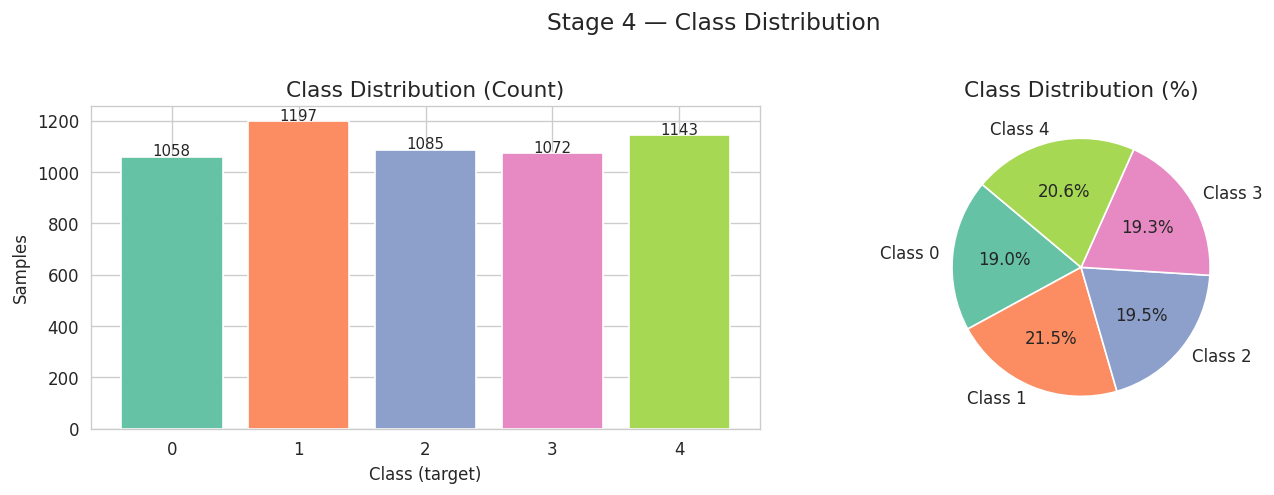

✓ Saved!


In [34]:
# ── 4.1 Class Distribution ────────────────────────────────────────────────────
dist   = df[LABEL_COL].value_counts().sort_index()
colors = sns.color_palette('Set2', n_classes)

print('Class distribution:')
for cls, cnt in dist.items():
    pct = cnt / len(df) * 100
    print(f'  Class {cls}: {cnt:>5} samples  ({pct:.1f}%)  {"█" * int(pct/2)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(dist.index.astype(str), dist.values, color=colors)
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Class (target)')
axes[0].set_ylabel('Samples')
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

axes[1].pie(dist.values, labels=[f'Class {c}' for c in dist.index],
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('Stage 4 — Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_1_class_distribution.png', bbox_inches='tight')
plt.show()
print('✓ Saved!')

Text length statistics:
       word_count  char_count  sent_count
count      5555.0      5555.0      5555.0
mean         74.3       499.4         1.0
std          75.3       511.0         0.0
min           1.0         4.0         1.0
25%          28.0       188.5         1.0
50%          54.0       364.0         1.0
75%          95.0       642.0         1.0
max        2180.0     14467.0         1.0


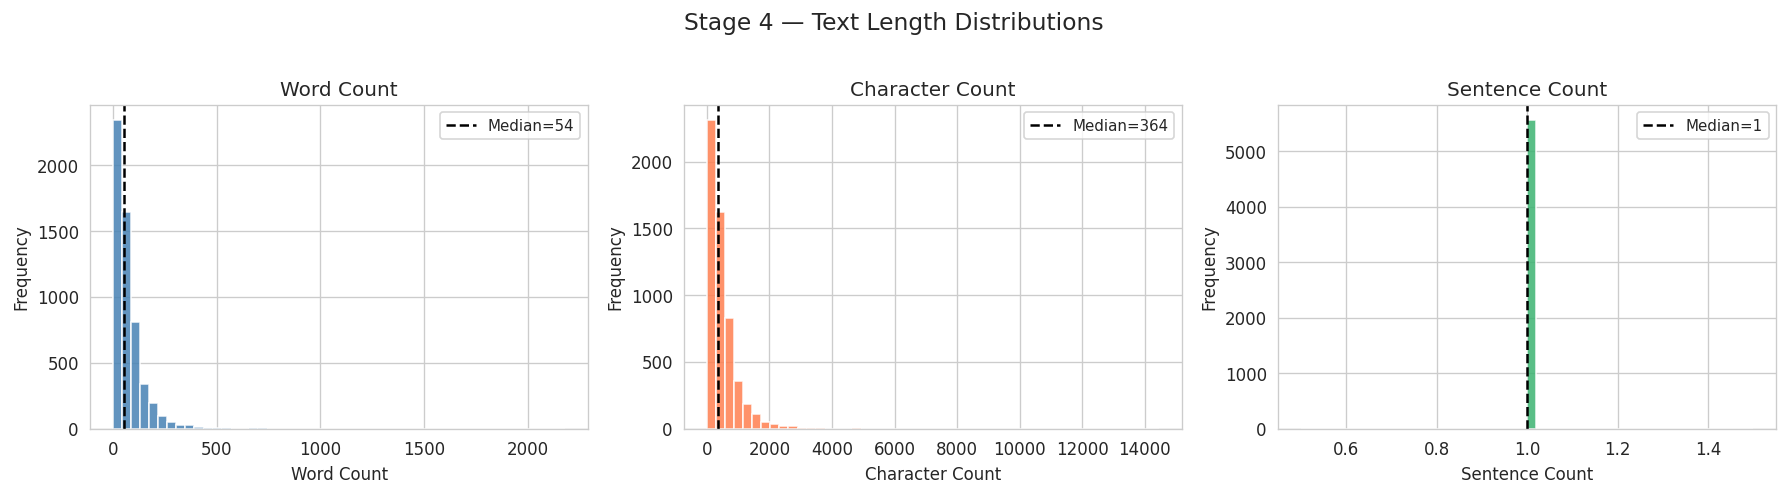

✓ Saved!


In [35]:
# ── 4.2 Text Length Analysis ──────────────────────────────────────────────────
df['word_count'] = df[TEXT_COL].apply(lambda x: len(x.split()))
df['char_count'] = df[TEXT_COL].apply(len)
df['sent_count'] = df[TEXT_COL].apply(lambda x: len(re.split(r'[.!?]+', x)))

print('Text length statistics:')
print(df[['word_count','char_count','sent_count']].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(
    axes,
    ['word_count', 'char_count', 'sent_count'],
    ['Word Count', 'Character Count', 'Sentence Count'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    ax.hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='black', linestyle='--',
               label=f'Median={df[col].median():.0f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Stage 4 — Text Length Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_2_text_lengths.png', bbox_inches='tight')
plt.show()
print('✓ Saved!')

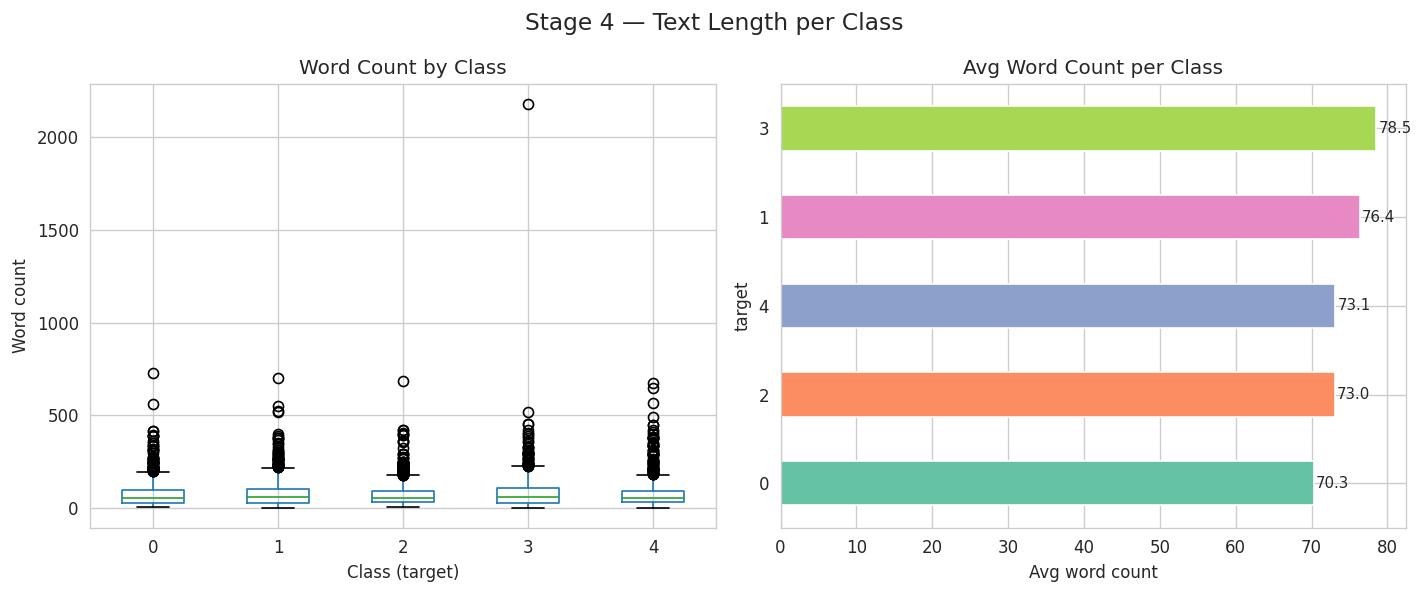

✓ Saved!


In [36]:
# ── 4.3 Word Count per Class ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='word_count', by=LABEL_COL, ax=axes[0])
axes[0].set_title('Word Count by Class')
axes[0].set_xlabel('Class (target)')
axes[0].set_ylabel('Word count')
plt.sca(axes[0]); plt.xticks(rotation=0)

mean_wc = df.groupby(LABEL_COL)['word_count'].mean().sort_values()
mean_wc.plot(kind='barh', ax=axes[1],
             color=sns.color_palette('Set2', len(mean_wc)))
axes[1].set_title('Avg Word Count per Class')
axes[1].set_xlabel('Avg word count')
for i, v in enumerate(mean_wc.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Stage 4 — Text Length per Class', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_3_length_per_class.png', bbox_inches='tight')
plt.show()
print('✓ Saved!')

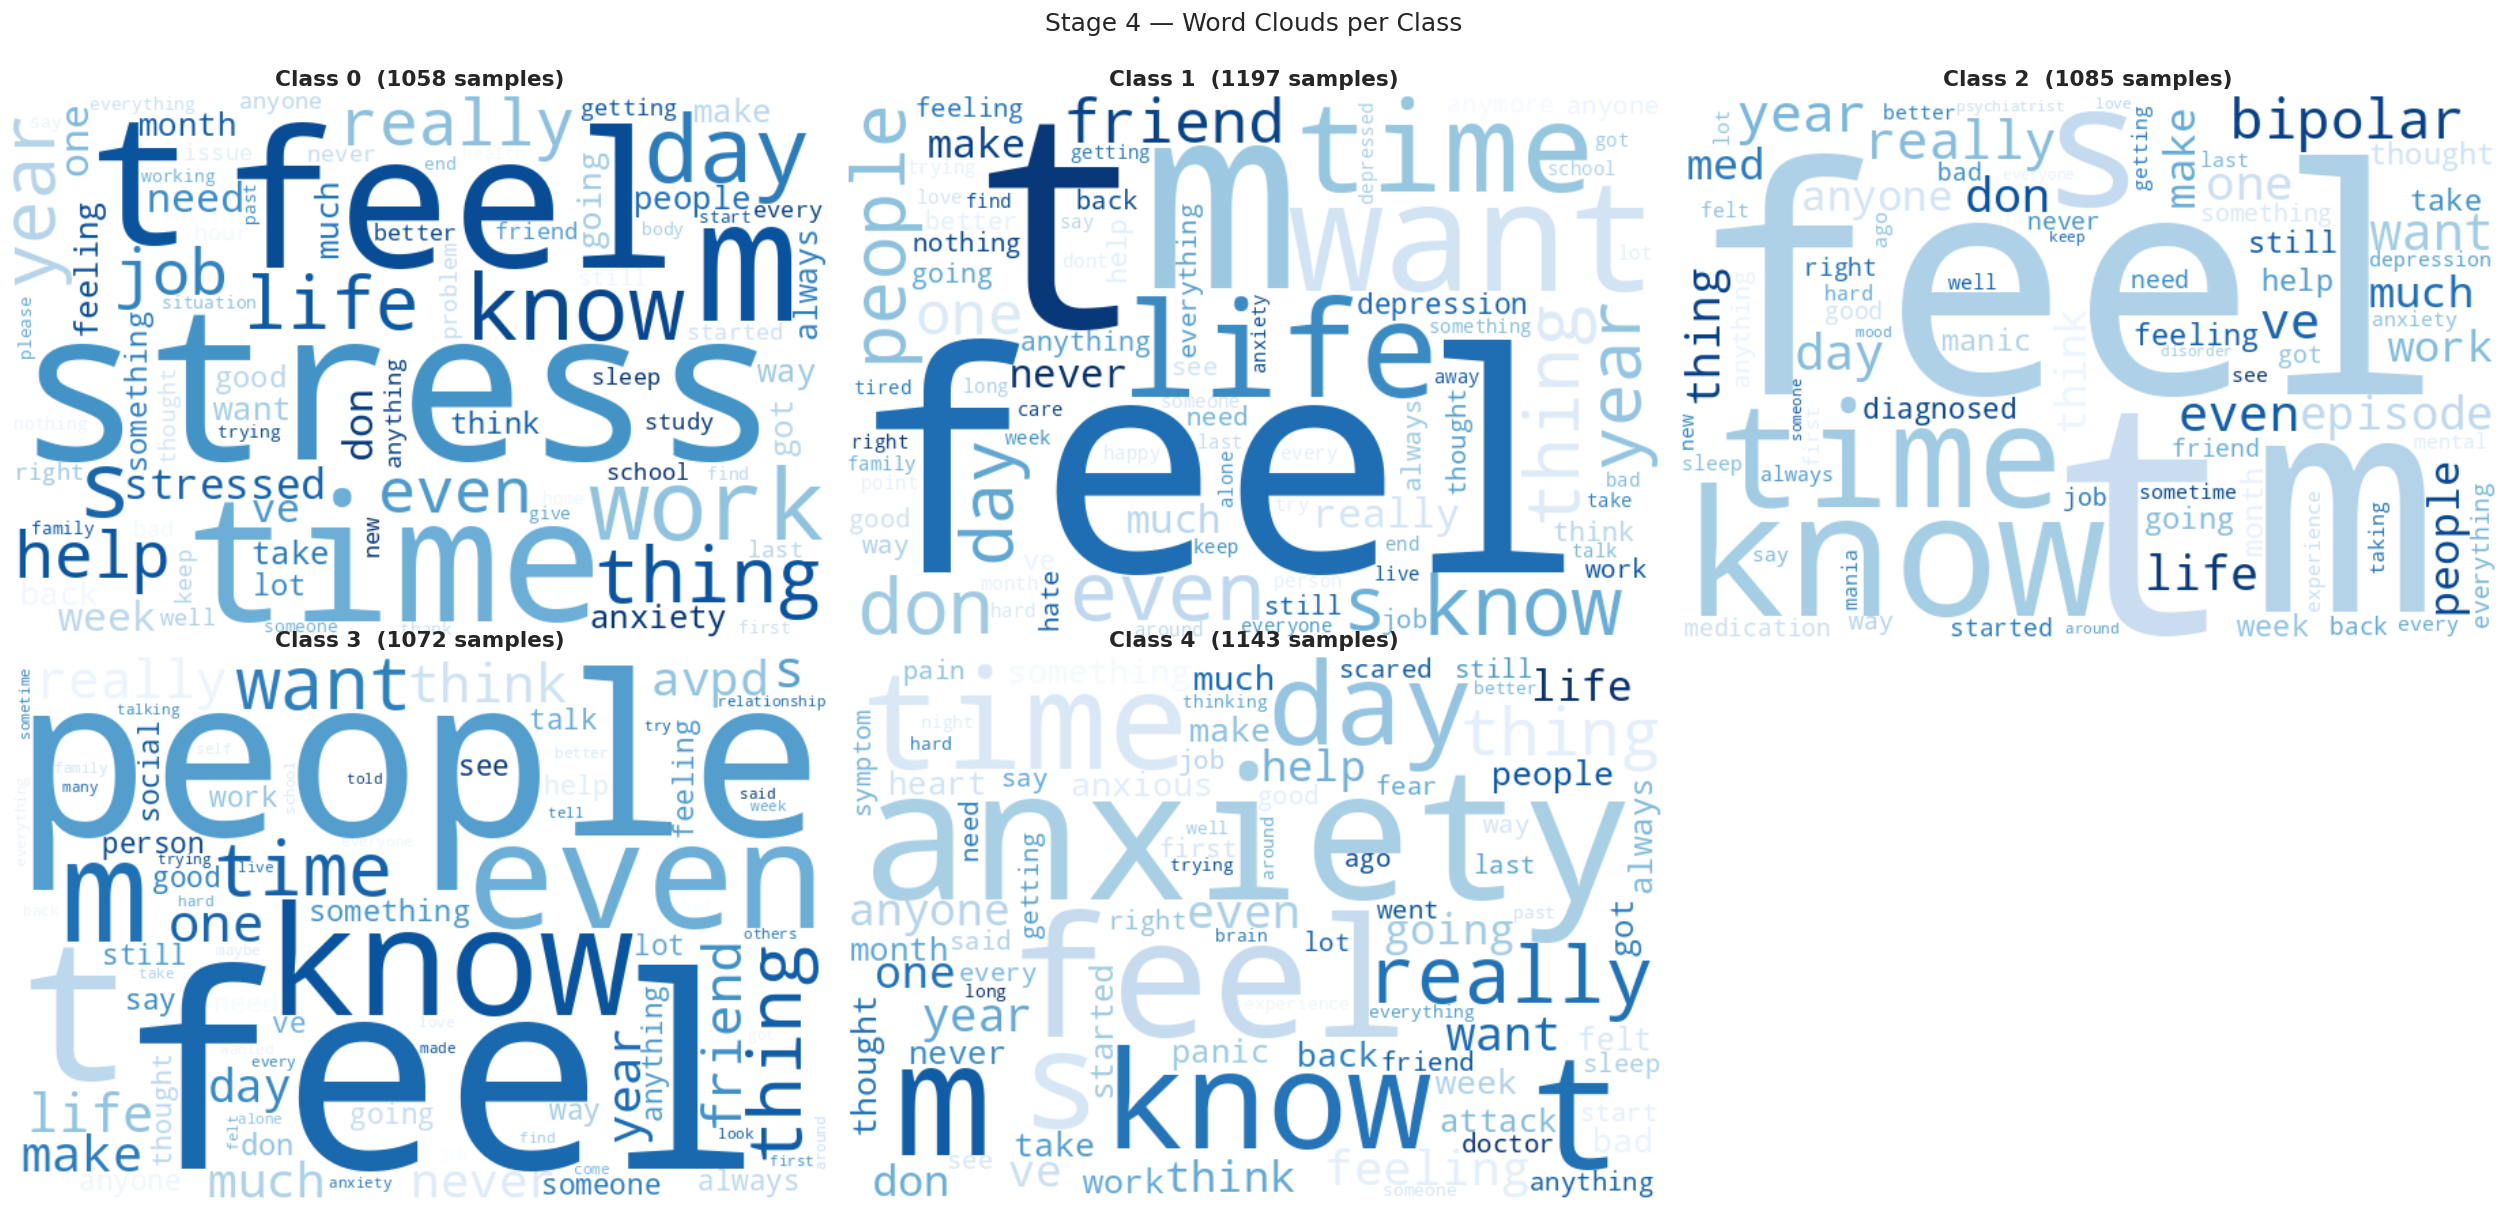

✓ Saved!

✅ STAGE 4 COMPLETE!


In [37]:
# ── 4.4 Word Clouds per Class ─────────────────────────────────────────────────
from wordcloud import WordCloud

ncols = min(3, n_classes)
nrows = (n_classes + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
axes = np.array(axes).flatten() if n_classes > 1 else [axes]

for i, cls in enumerate(classes):
    corpus = ' '.join(df[df[LABEL_COL]==cls][TEXT_COL].tolist())
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap='Blues', max_words=80,
                   collocations=False).generate(corpus)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Class {cls}  ({dist[cls]} samples)',
                      fontsize=13, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Stage 4 — Word Clouds per Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_4_wordclouds.png', bbox_inches='tight')
plt.show()
print('✓ Saved!')
print('\n✅ STAGE 4 COMPLETE!')

#Step 5: Feature Engineering

In [38]:
# ── 5.1 Extract 17 hand-crafted features ─────────────────────────────────────
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))
vader     = SentimentIntensityAnalyzer()

def extract_features(text):
    words   = text.split()
    n_words = len(words)

    neg_words = ['not','never','no','nobody','nothing','nowhere',
                 'neither','nor','none','cannot',"can't","won't",
                 "don't","didn't","doesn't","isn't","aren't"]

    vs   = vader.polarity_scores(text)
    blob = TextBlob(text)

    return {
        'word_count'      : n_words,
        'char_count'      : len(text),
        'avg_word_len'    : round(np.mean([len(w) for w in words]) if words else 0, 3),
        'stopword_ratio'  : round(sum(1 for w in words if w in STOPWORDS) / max(n_words,1), 3),
        'unique_ratio'    : round(len(set(words)) / max(n_words,1), 3),
        'punct_count'     : sum(1 for c in text if c in '.,!?;:'),
        'exclamation_cnt' : text.count('!'),
        'question_cnt'    : text.count('?'),
        'capital_ratio'   : round(sum(1 for c in text if c.isupper()) / max(len(text),1), 3),
        'negation_count'  : sum(1 for w in words if w.lower() in neg_words),
        'vader_pos'       : vs['pos'],
        'vader_neg'       : vs['neg'],
        'vader_neu'       : vs['neu'],
        'vader_compound'  : vs['compound'],
        'tb_polarity'     : round(blob.sentiment.polarity, 4),
        'tb_subjectivity' : round(blob.sentiment.subjectivity, 4),
    }

print('Extracting features — takes 1–2 minutes...')
feat_df = pd.DataFrame(df[TEXT_COL].apply(extract_features).tolist())
feat_df[LABEL_COL] = df[LABEL_COL].values
print(f'✓ Feature matrix: {feat_df.shape}')
feat_df.head(3)

Extracting features — takes 1–2 minutes...
✓ Feature matrix: (5555, 17)


,word_count,char_count,avg_word_len,stopword_ratio,unique_ratio,punct_count,exclamation_cnt,question_cnt,capital_ratio,negation_count,vader_pos,vader_neg,vader_neu,vader_compound,tb_polarity,tb_subjectivity,target
0,198,1468,6.419,0.005,0.737,0,0,0,0.0,2,0.276,0.189,0.535,0.9582,-0.0291,0.5181,1
1,379,2882,6.607,0.003,0.718,0,0,0,0.0,0,0.292,0.133,0.575,0.9969,0.0922,0.4795,1
2,7,44,5.429,0.000,1.000,0,0,0,0.0,0,0.000,0.211,0.789,-0.1531,0.0000,0.1429,1


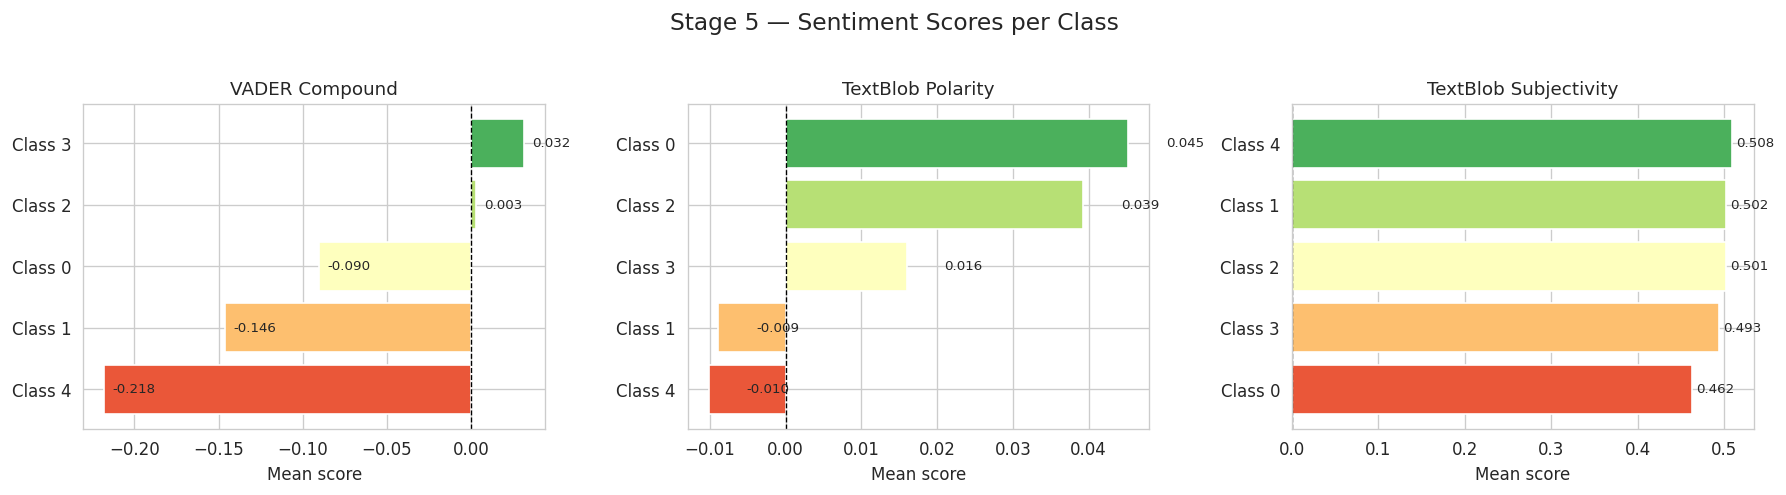

✓ Saved!


In [39]:
# ── 5.2 Sentiment per Class ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, title in zip(
    axes,
    ['vader_compound', 'tb_polarity', 'tb_subjectivity'],
    ['VADER Compound', 'TextBlob Polarity', 'TextBlob Subjectivity']
):
    means  = feat_df.groupby(LABEL_COL)[feat].mean().sort_values()
    colors = sns.color_palette('RdYlGn', len(means))
    bars   = ax.barh([f'Class {c}' for c in means.index], means.values, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mean score')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, means.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Stage 5 — Sentiment Scores per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feat_1_sentiment_per_class.png', bbox_inches='tight')
plt.show()
print('✓ Saved!')

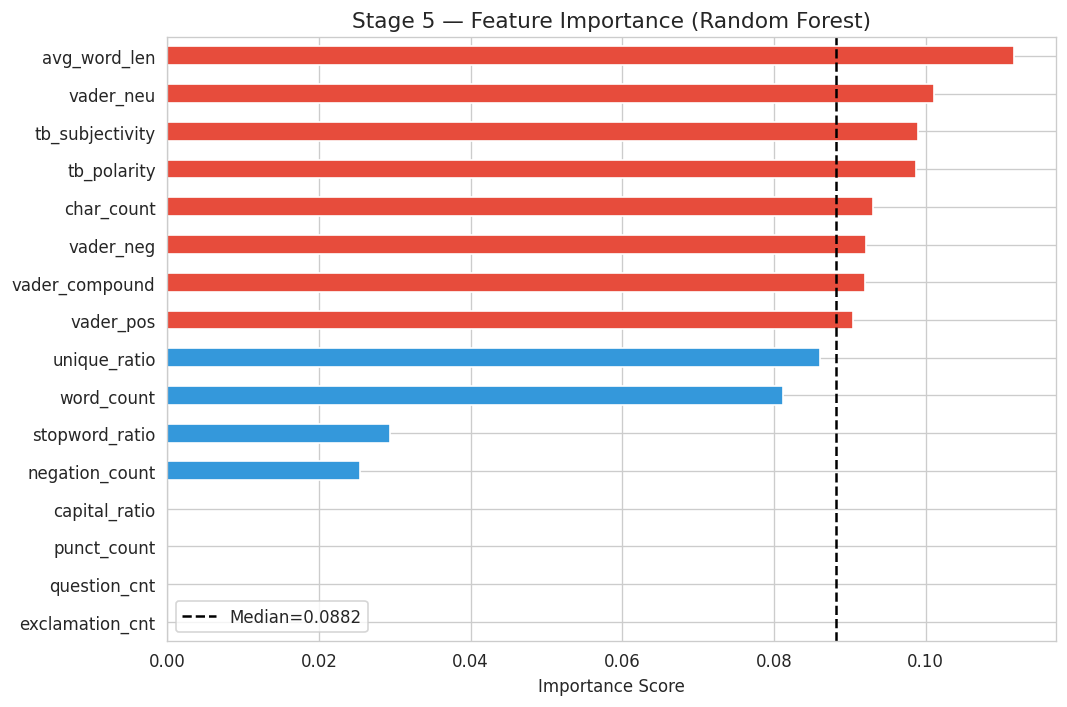

Top 5 features:
avg_word_len       0.111588
vader_neu          0.101142
tb_subjectivity    0.098934
tb_polarity        0.098712
char_count         0.093044

✅ STAGE 5 COMPLETE!


In [40]:
# ── 5.3 Feature Importance (Random Forest) ───────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_num = feat_df.drop(columns=[LABEL_COL])
y_enc = le.fit_transform(feat_df[LABEL_COL])

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_num, y_enc)

importances = pd.Series(rf.feature_importances_,
                        index=X_num.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v > importances.median() else '#3498db'
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Stage 5 — Feature Importance (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(importances.median(), color='black', linestyle='--',
           label=f'Median={importances.median():.4f}')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feat_2_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importances.sort_values(ascending=False).head(5).to_string())
print('\n✅ STAGE 5 COMPLETE!')

# Step 6 a :IDF-TF+SVM

In [41]:
# ── 6.0 Encode labels & split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Re-encode labels from the original df
le      = LabelEncoder()
texts   = df[TEXT_COL].tolist()
labels  = le.fit_transform(df[LABEL_COL]).tolist()
num_labels = len(le.classes_)

print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.10, random_state=SEED, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10/0.90, random_state=SEED, stratify=y_temp)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Label mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
Train: 4443  |  Val: 556  |  Test: 556


In [43]:
# ── 6A.1 Train TF-IDF + SVM ───────────────────────────────────────────────────
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=100_000, ngram_range=(1,2),
        sublinear_tf=True, min_df=2, max_df=0.95
    )),
    ('clf', CalibratedClassifierCV(
        LinearSVC(max_iter=2000, class_weight='balanced', random_state=SEED),
        cv=3, method='sigmoid'
    ))
])

grid_search = GridSearchCV(
    pipeline,
    param_grid={'clf__estimator__C': [0.01, 0.1, 1.0, 5.0, 10.0]},
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='f1_weighted', n_jobs=-1, verbose=1, refit=True
)

print('Training SVM with GridSearchCV... (~1–3 min)')
grid_search.fit(X_train, y_train)

best_svm   = grid_search.best_estimator_
best_C     = grid_search.best_params_['clf__estimator__C']
best_cv_f1 = grid_search.best_score_

print(f'\n✓ Best C     : {best_C}')
print(f'  Best CV F1 : {best_cv_f1:.4f}'
)

Training SVM with GridSearchCV... (~1–3 min)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

✓ Best C     : 1.0
  Best CV F1 : 0.7659


=== SVM RESULTS ===
Val  Accuracy : 0.8183
Val  F1(w)    : 0.8192
Test Accuracy : 0.8129
Test F1(w)    : 0.8141

Test Classification Report:
              precision    recall  f1-score   support

           0     0.8571    0.7358    0.7919       106
           1     0.7007    0.8000    0.7471       120
           2     0.9333    0.8991    0.9159       109
           3     0.8302    0.8224    0.8263       107
           4     0.7863    0.8070    0.7965       114

    accuracy                         0.8129       556
   macro avg     0.8215    0.8129    0.8155       556
weighted avg     0.8186    0.8129    0.8141       556



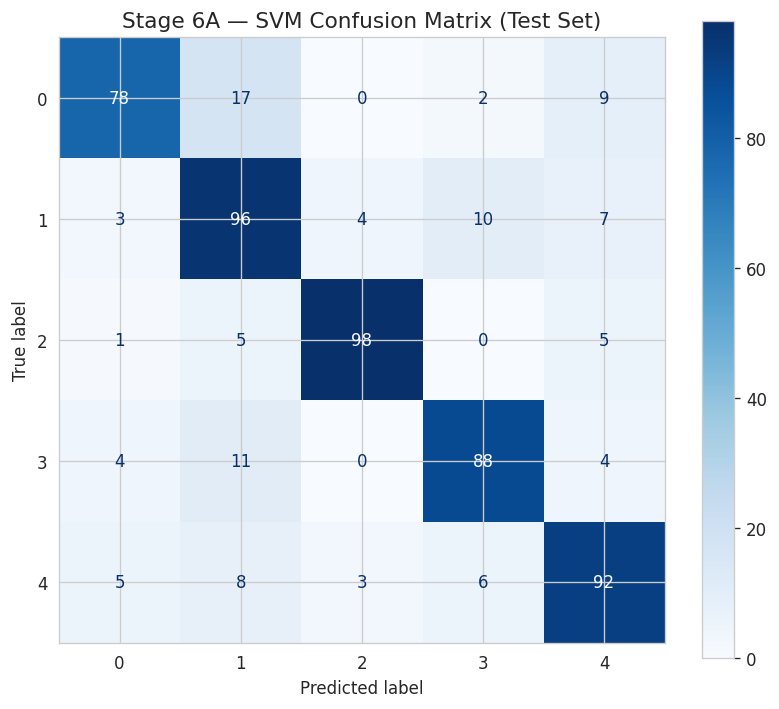


✓ SVM model saved!


In [44]:
# ── 6A.2 Evaluate SVM ─────────────────────────────────────────────────────────
y_val_pred  = best_svm.predict(X_val)
y_test_pred = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)

svm_val_acc  = accuracy_score(y_val,  y_val_pred)
svm_val_f1   = f1_score(y_val,  y_val_pred, average='weighted')
svm_test_acc = accuracy_score(y_test, y_test_pred)
svm_test_f1  = f1_score(y_test, y_test_pred, average='weighted')

print('=== SVM RESULTS ===')
print(f'Val  Accuracy : {svm_val_acc:.4f}')
print(f'Val  F1(w)    : {svm_val_f1:.4f}')
print(f'Test Accuracy : {svm_test_acc:.4f}')
print(f'Test F1(w)    : {svm_test_f1:.4f}')
print('\nTest Classification Report:')
print(classification_report(y_test, y_test_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Stage 6A — SVM Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Save SVM
SVM_DIR = OUTPUT_DIR / 'svm_model'
SVM_DIR.mkdir(exist_ok=True)
with open(SVM_DIR / 'tfidf_svm_pipeline.pkl', 'wb') as f:
    pickle.dump(best_svm, f)
with open(SVM_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('\n✓ SVM model saved!')

# Step 6:Bert Fine tune

In [46]:
# ── 6B.1 Setup BERT ───────────────────────────────────────────────────────────
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
                          BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from tqdm import tqdm
from pathlib import Path
import os # Import os for os.cpu_count()

SEED = 42 # Define SEED
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU! Go to Runtime → Change runtime type → T4 GPU')

# Config
MODEL_NAME   = 'bert-base-uncased'
MAX_LEN      = 256
BATCH_SIZE   = 16
EPOCHS       = 4
LR           = 2e-5

OUTPUT_DIR = Path('/content/outputs') # Define OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # Ensure parent directory exists
BERT_DIR     = OUTPUT_DIR / 'bert_model'
BERT_DIR.mkdir(exist_ok=True)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_token_type_ids=True,
            return_tensors='pt')
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'token_type_ids' : enc['token_type_ids'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

print(f'Loading tokenizer: {MODEL_NAME} ...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
nw = min(2, os.cpu_count() or 1)
train_loader = DataLoader(TextDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=nw)
val_loader   = DataLoader(TextDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=nw)
test_loader  = DataLoader(TextDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=nw)
print(f'✓ DataLoaders ready')

Device : cuda
GPU    : Tesla T4
Loading tokenizer: bert-base-uncased ...
✓ DataLoaders ready


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  BERT Training (4 epochs, batch=16)

Epoch 1/4


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (val_f1=0.7551)

Epoch 4/4


  Train — loss:0.7101  acc:0.7506
  Val   — loss:0.6955  acc:0.7680  f1:0.7679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (val_f1=0.7679)


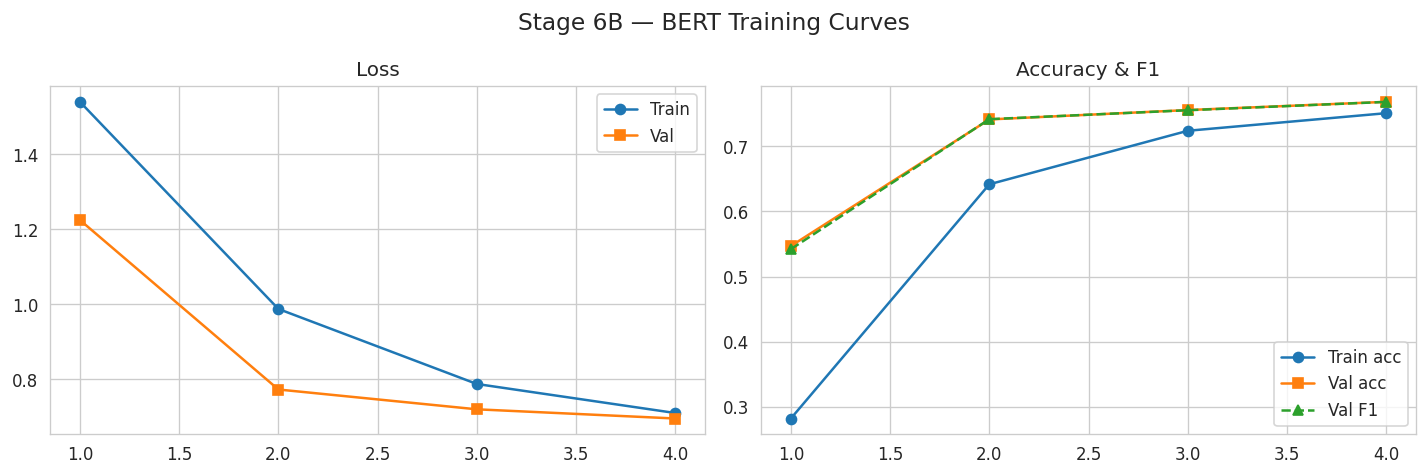


✅ STAGE 6 COMPLETE!


In [47]:
# ── 6B.2 Load model & train ───────────────────────────────────────────────────
import os, re, json, pickle, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score # Added for train_epoch and eval_epoch

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# --- Re-defining necessary global variables for robustness ---
# From FcYO4dhTTHz0 (Load dataset)
SEED = 42
random.seed(SEED); np.random.seed(SEED)

OUTPUT_DIR = Path('/content/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = '/content/mental-health-status-classification-from-social-media-text-predictive-project-3/cleaned_dataset.csv'

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['clean_text', 'target']).reset_index(drop=True)
df['clean_text'] = df['clean_text'].astype(str)

TEXT_COL  = 'clean_text'
LABEL_COL = 'target'

classes    = sorted(df[LABEL_COL].unique())
n_classes  = len(classes)

# From L1fzrYGwVA-M (6.0 Encode labels & split)
le      = LabelEncoder()
texts   = df[TEXT_COL].tolist()
labels  = le.fit_transform(df[LABEL_COL]).tolist()
num_labels = len(le.classes_)

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.10, random_state=SEED, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10/0.90, random_state=SEED, stratify=y_temp)

# From MOecXmLcVkYF (6B.1 Setup BERT)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_NAME   = 'bert-base-uncased'
MAX_LEN      = 256
BATCH_SIZE   = 16
EPOCHS       = 4
LR           = 2e-5
BERT_DIR     = OUTPUT_DIR / 'bert_model'
BERT_DIR.mkdir(exist_ok=True)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_token_type_ids=True,
            return_tensors='pt')
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'token_type_ids' : enc['token_type_ids'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
nw = min(2, os.cpu_count() or 1)
train_loader = DataLoader(TextDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=nw)
val_loader   = DataLoader(TextDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=nw)
test_loader  = DataLoader(TextDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=nw)
# --- End re-defining necessary global variables for robustness ---

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3,
    ignore_mismatched_sizes=True
).to(device)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)
no_decay     = ['bias', 'LayerNorm.weight']
optimizer    = AdamW([
    {'params': [p for n,p in model.named_parameters()
                if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n,p in model.named_parameters()
                if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
], lr=LR, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

def train_epoch(model, loader):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in tqdm(loader, desc='  Train', leave=False):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        tids = batch['token_type_ids'].to(device)
        lbl  = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask,
                     token_type_ids=tids, labels=lbl)
        out.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
        all_preds.extend(out.logits.argmax(-1).cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())
    return total_loss/len(loader), accuracy_score(all_labels, all_preds)

@torch.no_grad()
def eval_epoch(model, loader, split='Val'):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for batch in tqdm(loader, desc=f'  {split}', leave=False):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        tids = batch['token_type_ids'].to(device)
        lbl  = batch['label'].to(device)
        out  = model(input_ids=ids, attention_mask=mask,
                     token_type_ids=tids, labels=lbl)
        total_loss += out.loss.item()
        probs = torch.softmax(out.logits, dim=-1).cpu().numpy()
        all_preds.extend(probs.argmax(axis=-1).tolist())
        all_labels.extend(lbl.cpu().numpy())
        all_probs.extend(probs.tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss/len(loader), acc, f1, all_preds, all_labels, all_probs

# Training loop
history     = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[],'val_f1':[]}
best_val_f1 = 0.0

print(f'\n{"="*50}')
print(f'  BERT Training ({EPOCHS} epochs, batch={BATCH_SIZE})')
print(f'{"="*50}')

for epoch in range(1, EPOCHS+1):
    print(f'\nEpoch {epoch}/{EPOCHS}')
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc, vl_f1, _, _, _ = eval_epoch(model, val_loader)
    history['train_loss'].append(round(tr_loss,4))
    history['train_acc' ].append(round(tr_acc, 4))
    history['val_loss'  ].append(round(vl_loss,4))
    history['val_acc'   ].append(round(vl_acc, 4))
    history['val_f1'    ].append(round(vl_f1,  4))
    print(f'  Train — loss:{tr_loss:.4f}  acc:{tr_acc:.4f}')
    print(f'  Val   — loss:{vl_loss:.4f}  acc:{vl_acc:.4f}  f1:{vl_f1:.4f}')
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        model.save_pretrained(str(BERT_DIR / 'best_model'))
        tokenizer.save_pretrained(str(BERT_DIR / 'best_model'))
        print(f'  ✓ Best model saved (val_f1={best_val_f1:.4f})')

# Training curves
er = range(1, EPOCHS+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(er, history['train_loss'], 'o-', label='Train')
ax1.plot(er, history['val_loss'],   's-', label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(er, history['train_acc'], 'o-', label='Train acc')
ax2.plot(er, history['val_acc'],   's-', label='Val acc')
ax2.plot(er, history['val_f1'],    '^--', label='Val F1')
ax2.set_title('Accuracy & F1'); ax2.legend()
plt.suptitle('Stage 6B — BERT Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bert_training_curves.png', bbox_inches='tight')
plt.show()
print('\n✅ STAGE 6 COMPLETE!')

#Step 7:Evaluation Sensitivity and specificity

In [48]:
# ── 7.1 Sensitivity & Specificity function ────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def compute_sens_spec(y_true, y_pred, class_names):
    """One-vs-Rest sensitivity, specificity, precision, NPV, F1 per class."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rows = []
    for idx, name in enumerate(class_names):
        yt = (y_true == idx).astype(int)
        yp = (y_pred == idx).astype(int)
        TP = int(((yt==1)&(yp==1)).sum())
        TN = int(((yt==0)&(yp==0)).sum())
        FP = int(((yt==0)&(yp==1)).sum())
        FN = int(((yt==1)&(yp==0)).sum())
        sens = TP/(TP+FN) if (TP+FN)>0 else 0
        spec = TN/(TN+FP) if (TN+FP)>0 else 0
        prec = TP/(TP+FP) if (TP+FP)>0 else 0
        npv  = TN/(TN+FN) if (TN+FN)>0 else 0
        f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
        rows.append({'Class':str(name),
                     'TP':TP,'TN':TN,'FP':FP,'FN':FN,
                     'Sensitivity':round(sens,4),
                     'Specificity':round(spec,4),
                     'Precision'  :round(prec,4),
                     'NPV'        :round(npv, 4),
                     'F1'         :round(f1,  4)})
    return pd.DataFrame(rows)

print('✓ Function ready')

✓ Function ready


SVM — Sensitivity & Specificity:
Class  Sensitivity  Specificity  Precision    NPV     F1
    0       0.7358       0.9711     0.8571 0.9398 0.7919
    1       0.8000       0.9060     0.7007 0.9427 0.7471
    2       0.8991       0.9843     0.9333 0.9756 0.9159
    3       0.8224       0.9599     0.8302 0.9578 0.8263
    4       0.8070       0.9434     0.7863 0.9499 0.7965

  Macro Sensitivity : 0.8129
  Macro Specificity : 0.9529


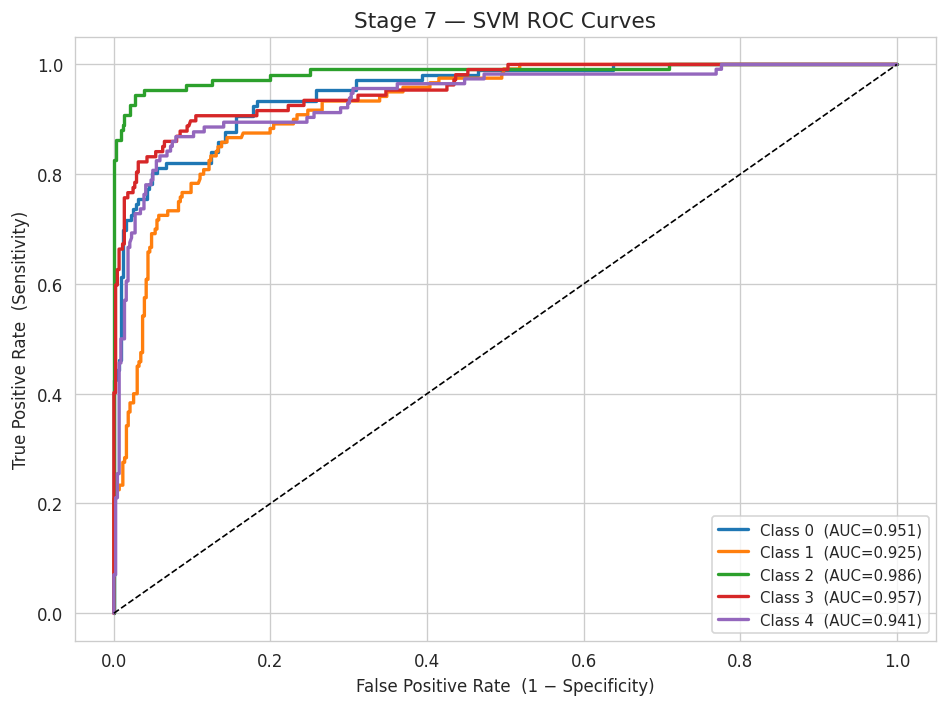

SVM Macro AUC : 0.9519


In [49]:
# ── 7.2 SVM — Sensitivity & Specificity ─────────────────────────────────────
svm_metrics = compute_sens_spec(y_test, y_test_pred, le.classes_)
print('SVM — Sensitivity & Specificity:')
print(svm_metrics[['Class','Sensitivity','Specificity','Precision','NPV','F1']].to_string(index=False))
print(f"\n  Macro Sensitivity : {svm_metrics['Sensitivity'].mean():.4f}")
print(f"  Macro Specificity : {svm_metrics['Specificity'].mean():.4f}")

# ── 7.3 SVM ─ ROC Curves ─────────────────────────────────────────────────────
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_test_bin  = label_binarize(np.array(y_test), classes=list(range(num_labels)))
colors_roc  = matplotlib.colormaps.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(8, 6))
auc_svm = []
for i, cls in enumerate(le.classes_):  # Fixed: le.classes_ is a property, not a method
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_svm[:, i])
    score = auc(fpr, tpr)
    auc_svm.append(score)
    ax.plot(fpr, tpr, color=colors_roc(i), lw=2,
            label=f'Class {cls}  (AUC={score:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate  (1 − Specificity)')
ax.set_ylabel('True Positive Rate  (Sensitivity)')
ax.set_title('Stage 7 — SVM ROC Curves', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage7_svm_roc.png', bbox_inches='tight')
plt.show()
print(f'SVM Macro AUC : {np.mean(auc_svm):.4f}')


In [50]:
# ── 7.4 BERT — Test Evaluation ────────────────────────────────────────────────
from sklearn.metrics import classification_report
from transformers import BertForSequenceClassification

best_bert = BertForSequenceClassification.from_pretrained(
    str(BERT_DIR / 'best_model')).to(device)

ts_loss, ts_acc, ts_f1, bert_preds, bert_labels, bert_probs = eval_epoch(
    best_bert, test_loader, 'Test')

print('=== BERT RESULTS ===')
print(f'Test Accuracy : {ts_acc:.4f}')
print(f'Test F1 (w)   : {ts_f1:.4f}')
print('\nClassification Report:')
print(classification_report(bert_labels, bert_preds, digits=4))

bert_metrics = compute_sens_spec(bert_labels, bert_preds, le.classes_)
print('\nBERT — Sensitivity & Specificity:')
print(bert_metrics[['Class','Sensitivity','Specificity','Precision','NPV','F1']].to_string(index=False))
print(f"\n  Macro Sensitivity : {bert_metrics['Sensitivity'].mean():.4f}")
print(f"  Macro Specificity : {bert_metrics['Specificity'].mean():.4f}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== BERT RESULTS ===
Test Accuracy : 0.7176
Test F1 (w)   : 0.7175

Classification Report:
              precision    recall  f1-score   support

           0     0.7358    0.7358    0.7358       106
           1     0.6560    0.6833    0.6694       120
           2     0.8257    0.8257    0.8257       109
           3     0.6733    0.6355    0.6538       107
           4     0.7043    0.7105    0.7074       114

    accuracy                         0.7176       556
   macro avg     0.7190    0.7182    0.7184       556
weighted avg     0.7177    0.7176    0.7175       556


BERT — Sensitivity & Specificity:
Class  Sensitivity  Specificity  Precision    NPV     F1
    0       0.7358       0.9378     0.7358 0.9378 0.7358
    1       0.6833       0.9014     0.6560 0.9118 0.6694
    2       0.8257       0.9575     0.8257 0.9575 0.8257
    3       0.6355       0.9265     0.6733 0.9143 0.6538
    4       0.7105       0.9231     0.7043 0.9252 0.7074

  Macro Sensitivity : 0.7182
  Macro Speci

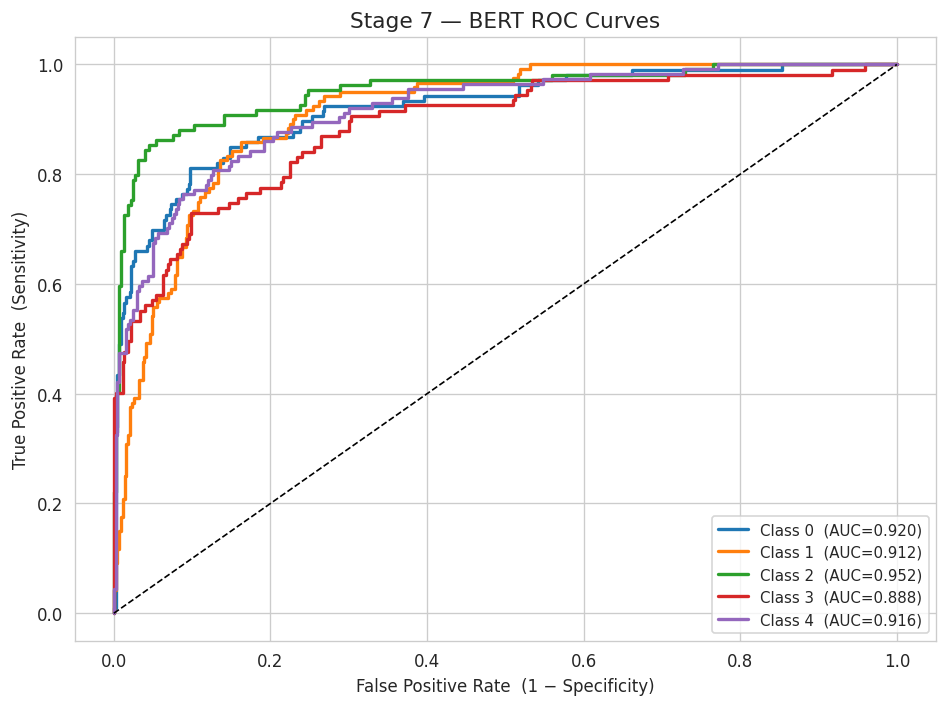

BERT Macro AUC : 0.9177


In [51]:
# ── 7.5 BERT — ROC Curves ─────────────────────────────────────────────────────
bert_probs_arr  = np.array(bert_probs)
bert_labels_bin = label_binarize(np.array(bert_labels), classes=list(range(num_labels)))

fig, ax = plt.subplots(figsize=(8, 6))
auc_bert = []
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(bert_labels_bin[:, i], bert_probs_arr[:, i])
    score = auc(fpr, tpr)
    auc_bert.append(score)
    ax.plot(fpr, tpr, color=colors_roc(i), lw=2,
            label=f'Class {cls}  (AUC={score:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate  (1 − Specificity)')
ax.set_ylabel('True Positive Rate  (Sensitivity)')
ax.set_title('Stage 7 — BERT ROC Curves', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage7_bert_roc.png', bbox_inches='tight')
plt.show()
print(f'BERT Macro AUC : {np.mean(auc_bert):.4f}')


  FINAL COMPARISON — SVM vs BERT
                   Test Accuracy  Test F1 (w)  Macro Sensitivity  Macro Specificity  Macro AUC
Model                                                                                         
TF-IDF + SVM              0.8129       0.8141             0.8129             0.9529     0.9519
BERT (fine-tuned)         0.7176       0.7175             0.7182             0.9293     0.9177


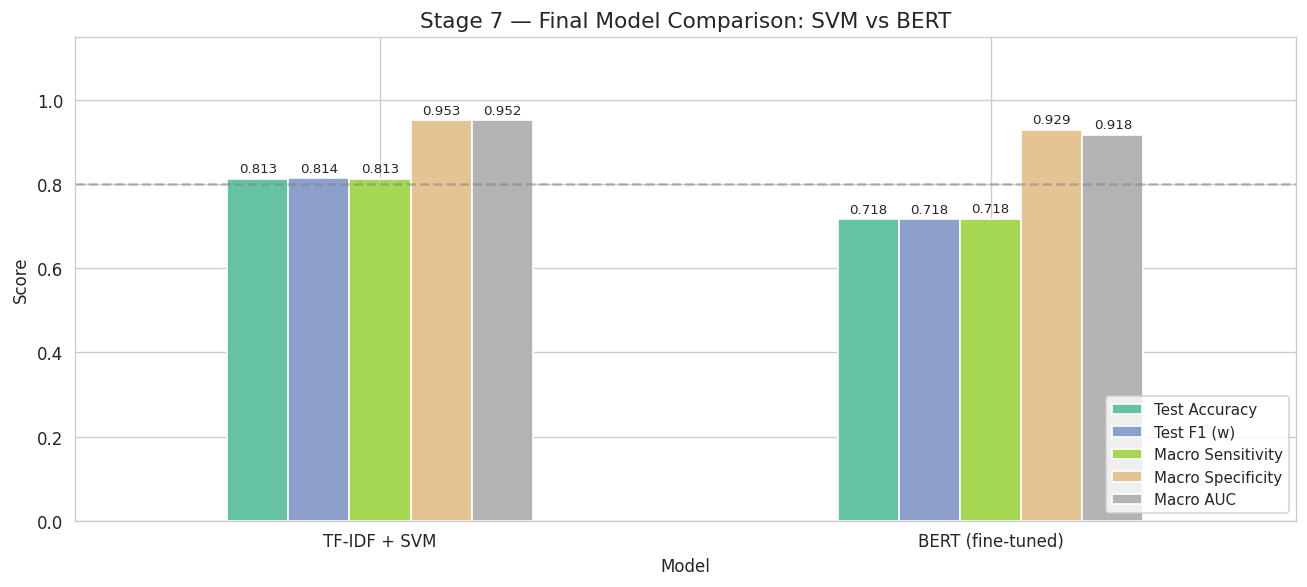


🎉 ALL STAGES COMPLETE!

📁 Output files saved to /content/outputs/
   bert_model
   bert_training_curves.png
   eda_1_class_distribution.png
   eda_2_text_lengths.png
   eda_3_length_per_class.png
   eda_4_wordclouds.png
   feat_1_sentiment_per_class.png
   feat_2_importance.png
   stage7_all_results.json
   stage7_bert_roc.png
   stage7_final_comparison.png
   stage7_svm_roc.png
   svm_confusion_matrix.png
   svm_model


In [52]:
# ── 7.6 Final Comparison — SVM vs BERT ───────────────────────────────────────
compare = pd.DataFrame({
    'Model'             : ['TF-IDF + SVM', 'BERT (fine-tuned)'],
    'Test Accuracy'     : [round(svm_test_acc, 4), round(ts_acc, 4)],
    'Test F1 (w)'       : [round(svm_test_f1,  4), round(ts_f1,  4)],
    'Macro Sensitivity' : [round(svm_metrics['Sensitivity'].mean(), 4),
                           round(bert_metrics['Sensitivity'].mean(), 4)],
    'Macro Specificity' : [round(svm_metrics['Specificity'].mean(), 4),
                           round(bert_metrics['Specificity'].mean(), 4)],
    'Macro AUC'         : [round(np.mean(auc_svm), 4),
                           round(np.mean(auc_bert), 4)],
}).set_index('Model')

print('\n' + '='*60)
print('  FINAL COMPARISON — SVM vs BERT')
print('='*60)
print(compare.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
compare.plot(kind='bar', ax=ax, rot=0, colormap='Set2', edgecolor='white')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Stage 7 — Final Model Comparison: SVM vs BERT', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage7_final_comparison.png', bbox_inches='tight')
plt.show()

# Save all results
all_results = {
    'SVM' : {'test_accuracy': round(svm_test_acc,4),
              'test_f1'      : round(svm_test_f1, 4),
              'macro_sensitivity': round(svm_metrics['Sensitivity'].mean(),4),
              'macro_specificity': round(svm_metrics['Specificity'].mean(),4),
              'macro_auc'   : round(np.mean(auc_svm),4)},
    'BERT': {'test_accuracy': round(ts_acc,4),
              'test_f1'      : round(ts_f1, 4),
              'macro_sensitivity': round(bert_metrics['Sensitivity'].mean(),4),
              'macro_specificity': round(bert_metrics['Specificity'].mean(),4),
              'macro_auc'   : round(np.mean(auc_bert),4)},
}
with open(OUTPUT_DIR / 'stage7_all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('\n🎉 ALL STAGES COMPLETE!')
print('\n📁 Output files saved to /content/outputs/')
import os
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'   {f}')